In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl

from sklearn.datasets import fetch_openml

In [ ]:
data = fetch_openml('mnist_784', version=1)
data.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [ ]:
X,y = data['data'] , data['target']
X.shape , y.shape

((70000, 784), (70000,))

In [ ]:
y = y.astype(np.uint8)

In [ ]:
X = X.to_numpy()

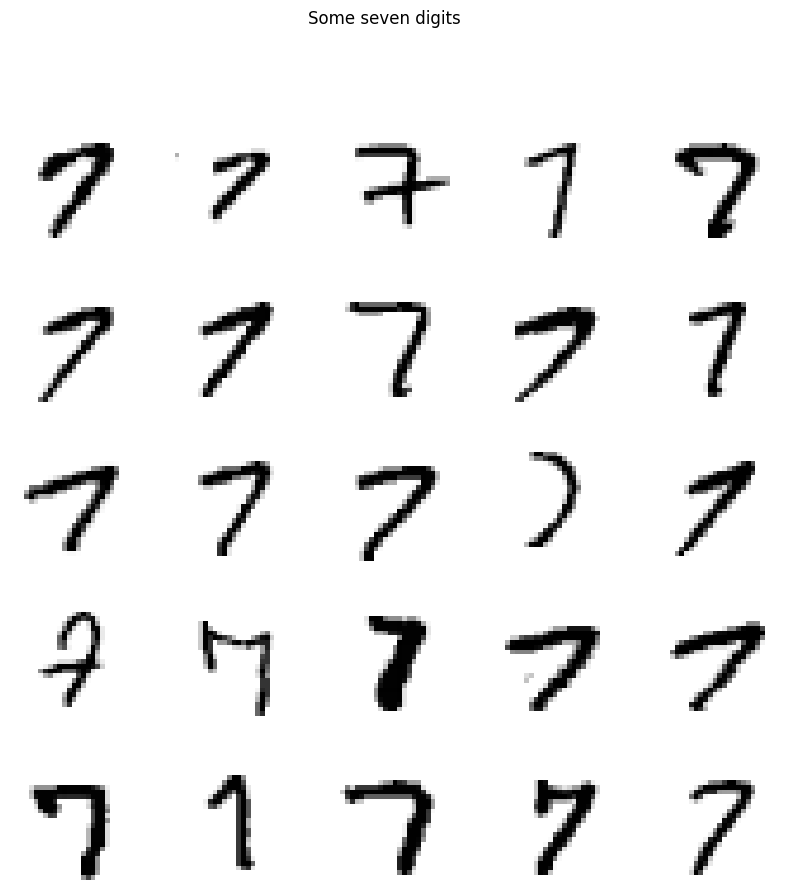

In [ ]:
seven = X[y == 7]

fig , ax = plt.subplots( 5,5, figsize = (10,10))
ax = ax.flatten()
plt.suptitle('Some seven digits')
for idx in range(25):
    ax[idx].imshow( seven[idx].reshape(28,28) , cmap = mpl.cm.binary,
           interpolation = 'nearest')
    ax[idx].axis('off')
plt.show()

In [ ]:
from sklearn.linear_model import SGDClassifier

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

test_y = ( y_test == 7 )
train_y = ( y_train == 7 )


In [ ]:
model = SGDClassifier ( penalty= None , loss = 'log_loss' , random_state= 26, max_iter = 10000)
model.fit( X_train , train_y )

In [ ]:
model.predict ( [X[y==7][225]] )

In [ ]:
plt.figure()
plt.imshow( X[y==7][225].reshape(28,28) , cmap = mpl.cm.binary,
           interpolation = 'nearest')
plt.axis('off')
plt.show()

In [ ]:
print(model.predict ( [X[y==7][500]] ))

plt.figure()
plt.imshow( X[y==7][500].reshape(28,28) , cmap = mpl.cm.binary,
           interpolation = 'nearest')
plt.axis('off')
plt.show()

The model classified as correct 7 and when the 7 was somewhat different it predicted false, it is based on stochastic gradient descent with hidden layers

In [ ]:
from sklearn.metrics import precision_score , recall_score

from sklearn.model_selection import cross_val_predict , cross_val_score , StratifiedKFold

skfolds = StratifiedKFold (random_state = 26 , n_splits = 5, shuffle=True )
scores = cross_val_score( model, X_train ,train_y, scoring = 'accuracy' ,  cv = skfolds)
scores.mean()